# Bayesian MVP — Orbitrap HILIC negESI

Refitted on Oliver's 2026-03-19 Orbitrap spreadsheet.

**Key changes from TTOF proposal_mvp.ipynb:**
- Explicit TP/FP labels (rows 0–1297 = TP, yy_ = FP) instead of InChIKey14 inference
- 112 solid TPs held out for testing (not used in fitting)
- PubMed/patent prior instead of BinBase quality gate
- peak_purity / gaussian_similarity removed
- Only annotated subset scored (1,298 TP + 215 FP)
- Train/test split: 1,186 TP + 215 FP (train), 112 solid TP (test)

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem.inchi import MolToInchi, InchiToInchiKey
    RDLogger.DisableLog('rdApp.*')
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print('WARNING: RDKit not available — InChIKey14 computation disabled')

# ── Paths ─────────────────────────────────────────────────────────────────
SPECTRA_PATH   = '../data/masswiki_Orbitrap HILIC negESI_2026-03-19.xlsx'
HITS_PATH      = '../data/library_hits/orbitrap_hilic_neg_masswiki_hits.csv'
SOLID_TP_PATH  = '../data/solid_tp.csv'
PRIOR_CACHE    = '../data/pubmed_prior_cache.json'
INCHIKEY_CACHE = '../data/inchikey_cache.json'
OUT_DIR        = '../results/orbitrap_mvp'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────
SIGMA_BROAD    = 10.0    # ppm — null mass spread (tighter for Orbitrap vs TTOF's 50 ppm)
SIGMA_RT_BROAD = 300.0   # s  — null RT spread
P_MS1_NULL     = norm.pdf(0, 0, SIGMA_BROAD)
P_RT_NULL      = norm.pdf(0, 0, SIGMA_RT_BROAD)
NOTA_THRESH    = 0.6
PRIOR_FLOOR    = 0.01    # floor prior for compounds without PubChem data

print(f'P_MS1_NULL = {P_MS1_NULL:.6f}  (N(0,0,{SIGMA_BROAD}ppm))')
print(f'P_RT_NULL  = {P_RT_NULL:.6f}  (N(0,0,{SIGMA_RT_BROAD}s))')

P_MS1_NULL = 0.039894  (N(0,0,10.0ppm))
P_RT_NULL  = 0.001330  (N(0,0,300.0s))


## 1. Load & Label Spectra

In [2]:
# ── Load Oliver's spreadsheet ─────────────────────────────────────────────
spectra_raw = pd.read_excel(SPECTRA_PATH, header=4)
print(f'Loaded {len(spectra_raw):,} spectra')

# ── Explicit labels ───────────────────────────────────────────────────────
# Rows 0-1297: re-annotated, believed correct → TP
# yy_ prefix: flagged suspicious → FP
# zz_ prefix: not real spectra → exclude from scoring
spectra_raw['label'] = 'unlabeled'
spectra_raw.loc[:1297, 'label'] = 'TP'
spectra_raw.loc[spectra_raw['name'].str.startswith('yy_', na=False), 'label'] = 'FP'
spectra_raw.loc[spectra_raw['name'].str.startswith('zz_', na=False), 'label'] = 'TN'

# ── Load solid TP holdout ─────────────────────────────────────────────────
solid_tp = pd.read_csv(SOLID_TP_PATH)
holdout_wids = set(solid_tp['wiki_id'])
spectra_raw['holdout'] = spectra_raw['wiki_id'].isin(holdout_wids)

# ── Filter to annotated subset only ──────────────────────────────────────
# TP + FP labels; exclude zz_ (not real) and unlabeled
spectra = spectra_raw[spectra_raw['label'].isin(['TP', 'FP'])].copy()

print(f'\nLabel distribution:')
print(spectra_raw['label'].value_counts().to_string())
print(f'\nAnnotated subset (TP + FP): {len(spectra):,} spectra')
print(f'  Holdout (solid TP, test only): {spectra["holdout"].sum()}')
print(f'  Training set (TP): {((spectra["label"] == "TP") & ~spectra["holdout"]).sum()}')
print(f'  Training set (FP): {(spectra["label"] == "FP").sum()}')

Loaded 5,971 spectra

Label distribution:
label
unlabeled    4456
TP           1298
FP            215
TN              2

Annotated subset (TP + FP): 1,513 spectra
  Holdout (solid TP, test only): 112
  Training set (TP): 1186
  Training set (FP): 215


## 2. Load & Join Library Hits

In [3]:
# ── InChIKey cache ───────────────────────────────────────────────────────
ik_cache = {}
if os.path.exists(INCHIKEY_CACHE):
    with open(INCHIKEY_CACHE) as f:
        ik_cache = json.load(f)
    print(f'Loaded InChIKey cache: {len(ik_cache):,} entries')

def smiles_to_ik14(smiles):
    if not RDKIT_AVAILABLE or not isinstance(smiles, str) or not smiles.strip():
        return None
    if smiles in ik_cache:
        return ik_cache[smiles].get('ik14')
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    ik = InchiToInchiKey(MolToInchi(mol))
    if ik:
        ik_cache[smiles] = {'ik14': ik[:14], 'inchikey': ik}
        return ik[:14]
    return None

def smiles_to_inchikey(smiles):
    if not RDKIT_AVAILABLE or not isinstance(smiles, str) or not smiles.strip():
        return None
    if smiles in ik_cache:
        return ik_cache[smiles].get('inchikey')
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    ik = InchiToInchiKey(MolToInchi(mol))
    if ik:
        ik_cache[smiles] = {'ik14': ik[:14], 'inchikey': ik}
    return ik

# ── Load library hits ─────────────────────────────────────────────────────
hits_raw = pd.read_csv(HITS_PATH, low_memory=False)
hits_raw = hits_raw.rename(columns={'id': 'library_id', 'lib_name': 'name'})
print(f'Loaded {len(hits_raw):,} library hits')
print(f'Columns: {list(hits_raw.columns)}')

# ── Compute InChIKey14 for library hits (with cache) ──────────────────────
if RDKIT_AVAILABLE and 'smiles' in hits_raw.columns:
    print('Computing InChIKey14 for hits (using cache)...')
    hits_raw['ik14'] = hits_raw['smiles'].apply(smiles_to_ik14)
    hits_raw['inchikey'] = hits_raw['smiles'].apply(smiles_to_inchikey)
    with open(INCHIKEY_CACHE, 'w') as f:
        json.dump(ik_cache, f)
    print(f'  ik14: {hits_raw["ik14"].notna().sum():,}/{len(hits_raw):,}')
    print(f'  InChIKey cache saved: {len(ik_cache):,} entries')
else:
    hits_raw['ik14'] = None
    hits_raw['inchikey'] = None

Loaded InChIKey cache: 19,417 entries


Loaded 267,645 library hits
Columns: ['wiki_id', 'hit_source', 'db', 'library_id', 'name', 'adduct', 'lib_precursor_mz', 'entropy_similarity', 'library_type', 'lib_rt', 'ri', 'rank', 'smiles', 'predicted_rt_hilic', 'predicted_rt_rp', 'anno_delta_rt', 'delta_predicted_rt']
Computing InChIKey14 for hits (using cache)...


  ik14: 257,058/267,645
  InChIKey cache saved: 19,417 entries


In [4]:
# ── Spectra columns for join ─────────────────────────────────────────────
spec_cols = spectra[['wiki_id', 'rt', 'precursor_mz', 'entropy',
                      'name', 'smiles', 'label', 'holdout']].copy()
spec_cols = spec_cols.rename(columns={'name': 'obs_name', 'smiles': 'obs_smiles'})

# ── Compute obs InChIKey14 from spectra SMILES ────────────────────────────
if RDKIT_AVAILABLE and spec_cols['obs_smiles'].notna().any():
    spec_cols['obs_ik14'] = spec_cols['obs_smiles'].apply(smiles_to_ik14)
    with open(INCHIKEY_CACHE, 'w') as f:
        json.dump(ik_cache, f)
    print(f'obs_ik14: {spec_cols["obs_ik14"].notna().sum():,}/{len(spec_cols):,}')
else:
    spec_cols['obs_ik14'] = None

# ── Join hits to spectra ──────────────────────────────────────────────────
joint = hits_raw.merge(spec_cols, on='wiki_id', how='inner')
print(f'Joined: {len(joint):,} rows, {joint["wiki_id"].nunique():,} spectra')

# ── delta_ppm: (obs - lib) / lib * 1e6 ───────────────────────────────────
joint['lib_precursor_mz'] = pd.to_numeric(joint['lib_precursor_mz'], errors='coerce')
joint['delta_ppm'] = (
    (joint['precursor_mz'] - joint['lib_precursor_mz'])
    / joint['lib_precursor_mz'] * 1e6
)

# ── delta_rt per hit_source ───────────────────────────────────────────────
joint['delta_rt'] = np.nan
anno_mask = joint['hit_source'] == 'annotation'
ref_mask  = joint['hit_source'] == 'reference'

if 'anno_delta_rt' in joint.columns:
    joint.loc[anno_mask, 'delta_rt'] = pd.to_numeric(
        joint.loc[anno_mask, 'anno_delta_rt'], errors='coerce')
if 'predicted_rt_hilic' in joint.columns:
    joint.loc[ref_mask, 'delta_rt'] = (
        joint.loc[ref_mask, 'rt']
        - pd.to_numeric(joint.loc[ref_mask, 'predicted_rt_hilic'], errors='coerce'))

n_anno = joint.loc[anno_mask, 'delta_rt'].notna().sum()
n_ref  = joint.loc[ref_mask,  'delta_rt'].notna().sum()
print(f'RT: annotation={n_anno:,}, reference={n_ref:,}')

# ── Correctness flag ──────────────────────────────────────────────────────
if joint['obs_ik14'].notna().any() and joint['ik14'].notna().any():
    joint['correct'] = (
        joint['ik14'].notna() & joint['obs_ik14'].notna() &
        (joint['ik14'] == joint['obs_ik14'])
    )
    name_fallback = (
        joint['name'].str.strip().str.lower() ==
        joint['obs_name'].fillna('').str.strip().str.lower()
    )
    joint['correct'] = joint['correct'] | (joint['ik14'].isna() & name_fallback)
    print(f'Ground truth: InChIKey14 + name fallback')
else:
    joint['correct'] = (
        joint['name'].str.strip().str.lower() ==
        joint['obs_name'].fillna('').str.strip().str.lower()
    )
    print(f'Ground truth: name match')

print(f'Correct hits: {joint["correct"].sum():,}')

# ── has_library_match: TP spectra where correct compound exists ────────────
has_match = joint.groupby('wiki_id')['correct'].any()
joint['has_library_match'] = joint['wiki_id'].map(has_match)

# ── Dedup: keep max entropy_similarity per (spectrum, lib_name) ──────────
joint = (
    joint.sort_values('entropy_similarity', ascending=False)
    .drop_duplicates(subset=['wiki_id', 'name'])
    .reset_index(drop=True)
)
print(f'After dedup: {len(joint):,} rows')
joint[['delta_ppm', 'entropy_similarity', 'entropy', 'delta_rt']].describe().round(3)

obs_ik14: 1,510/1,513


Joined: 120,828 rows, 1,513 spectra
RT: annotation=12,778, reference=96,219


Ground truth: InChIKey14 + name fallback
Correct hits: 44,602
After dedup: 28,513 rows


,delta_ppm,entropy_similarity,entropy,delta_rt
count,28513.000,28513.000,28513.000,25842.000
mean,0.709,0.520,1.658,10.463
std,14.264,0.326,0.735,40.418
min,-100.144,0.001,0.000,-303.729
25%,-0.697,0.188,1.154,-8.636
50%,0.221,0.567,1.669,2.919
75%,1.817,0.812,2.189,23.182
max,117.075,1.000,3.675,312.773


## 3. Build Confusable Sets + Train/Test Split

In [5]:
# ── Confusable sets: filter by entropy_similarity threshold ───────────────
MS2_MIN = 0.75
joint_filt = joint[joint['entropy_similarity'] >= MS2_MIN].copy()
print(f'After entropy_similarity >= {MS2_MIN}: {len(joint_filt):,} rows, '
      f'{joint_filt["wiki_id"].nunique():,} spectra')

# ── Sim gap: for each hit, how far it beats the next-ranked hit ──────────
# Sort descending by sim within each spectrum; last hit gets gap = 0.
joint_filt = joint_filt.sort_values(
    ['wiki_id', 'entropy_similarity'], ascending=[True, False]
).copy()
_sim_next = joint_filt.groupby('wiki_id')['entropy_similarity'].shift(-1)
joint_filt['sim_gap'] = (
    joint_filt['entropy_similarity'] - _sim_next.fillna(joint_filt['entropy_similarity'])
).clip(lower=0.0)

# ── Define train / test subsets ───────────────────────────────────────────
train_wids = set(
    joint_filt[
        ((joint_filt['label'] == 'TP') & ~joint_filt['holdout']) |
        (joint_filt['label'] == 'FP')
    ]['wiki_id']
)
test_wids = set(joint_filt[joint_filt['holdout']]['wiki_id'])

joint_train = joint_filt[joint_filt['wiki_id'].isin(train_wids)].copy()
joint_test  = joint_filt[joint_filt['wiki_id'].isin(test_wids)].copy()

print(f'\nTrain set: {joint_train["wiki_id"].nunique():,} spectra, {len(joint_train):,} hits')
print(f'  TP spectra: {joint_train[joint_train["label"]=="TP"]["wiki_id"].nunique():,}')
print(f'  FP spectra: {joint_train[joint_train["label"]=="FP"]["wiki_id"].nunique():,}')
print(f'Test set:  {joint_test["wiki_id"].nunique():,} solid TP spectra, {len(joint_test):,} hits')

# ── Solvable: TP spectra where correct compound IS in the library ─────────
solvable_train = joint_train[
    (joint_train['label'] == 'TP') & joint_train['has_library_match']
]
correct_hits   = solvable_train[solvable_train['correct']]
incorrect_hits = solvable_train[~solvable_train['correct']]

print(f'\nSolvable train TP: {solvable_train["wiki_id"].nunique():,} spectra')
print(f'  correct_hits: {len(correct_hits):,}')
print(f'  incorrect_hits: {len(incorrect_hits):,}')
print(f'\nsim_gap — correct hits:   mean={correct_hits["sim_gap"].mean():.4f}  '
      f'median={correct_hits["sim_gap"].median():.4f}')
print(f'sim_gap — incorrect hits: mean={incorrect_hits["sim_gap"].mean():.4f}  '
      f'median={incorrect_hits["sim_gap"].median():.4f}')


After entropy_similarity >= 0.75: 9,060 rows, 1,513 spectra

Train set: 1,401 spectra, 7,956 hits
  TP spectra: 1,186
  FP spectra: 215
Test set:  112 solid TP spectra, 1,104 hits

Solvable train TP: 1,186 spectra
  correct_hits: 4,779
  incorrect_hits: 1,935

sim_gap — correct hits:   mean=0.0267  median=0.0036
sim_gap — incorrect hits: mean=0.0094  median=0.0014


In [6]:
# Quick sanity check
print(f'joint columns: {list(joint.columns)}')
print(f'correct: {joint["correct"].sum():,}  has_match: {joint["has_library_match"].sum():,}')
print(f'label dist: {joint["label"].value_counts().to_dict()}')

joint columns: ['wiki_id', 'hit_source', 'db', 'library_id', 'name', 'adduct', 'lib_precursor_mz', 'entropy_similarity', 'library_type', 'lib_rt', 'ri', 'rank', 'smiles', 'predicted_rt_hilic', 'predicted_rt_rp', 'anno_delta_rt', 'delta_predicted_rt', 'ik14', 'inchikey', 'rt', 'precursor_mz', 'entropy', 'obs_name', 'obs_smiles', 'label', 'holdout', 'obs_ik14', 'delta_ppm', 'delta_rt', 'correct', 'has_library_match']
correct: 10,502  has_match: 28,488
label dist: {'TP': 24185, 'FP': 4328}


In [ ]:
## 9b. Diagnostic: InChIKey14 vs Name-Only Labeling

# ── Step 1: Coverage check ───────────────────────────────────────────────────
n_hit_ik14 = joint['ik14'].notna().sum()
n_spec_ik14 = joint['obs_ik14'].notna().sum()
n_both_ik14 = (joint['ik14'].notna() & joint['obs_ik14'].notna()).sum()
print(f'Hit IK14 coverage:  {n_hit_ik14:,}/{len(joint):,}')
print(f'Spec IK14 coverage: {n_spec_ik14:,}/{len(joint):,}')
print(f'Both IK14 present:  {n_both_ik14:,}/{len(joint):,}')
print()

# ── Step 2: Compare IK14 label vs name-only label ────────────────────────────
# Recompute name-only labeling for comparison
name_label = (
    joint['name'].str.strip().str.lower() ==
    joint['obs_name'].fillna('').str.strip().str.lower()
)

# Where both IK14 are available, see if they agree
mask = joint['ik14'].notna() & joint['obs_ik14'].notna()
ik14_label = joint.loc[mask, 'ik14'] == joint.loc[mask, 'obs_ik14']
name_label_sub = name_label[mask]

agree = (ik14_label == name_label_sub).sum()
disagree = (ik14_label != name_label_sub).sum()

flipped_to_correct = (~name_label_sub & ik14_label).sum()
flipped_to_incorrect = (name_label_sub & ~ik14_label).sum()

print(f'IK14 vs Name-only labeling (when both present):' )
print(f'  Agree:                      {agree:,}')
print(f'  Disagree:                   {disagree:,}')
print(f'    Name=wrong, IK14=correct: {flipped_to_correct:,} (synonyms/stereoisomers)')
print(f'    Name=correct, IK14=wrong: {flipped_to_incorrect:,} (should be rare)')
print()

# ── Step 3: Inspect the flipped hits ────────────────────────────────────────
print('Examples: Name=wrong but IK14=correct (mislabeled in name-only scheme):')
flip_mask = mask & ~name_label_sub & ik14_label
if flip_mask.any():
    flip_df = joint[flip_mask][[
        'wiki_id', 'name', 'obs_name', 'ik14', 'obs_ik14', 'entropy_similarity', 'label'
    ]].head(10)
    print(flip_df.to_string(index=False))
else:
    print('  (none found)')
print()

# ── Step 4: Quantify training set contamination ────────────────────────────────
train_tp_mask = (joint['label'] == 'TP') & ~joint['holdout']
incorrect_hits_train = joint[train_tp_mask & ~joint['correct']]

flipped = incorrect_hits_train[
    incorrect_hits_train['ik14'].notna() & 
    incorrect_hits_train['obs_ik14'].notna() &
    (incorrect_hits_train['ik14'] == incorrect_hits_train['obs_ik14'])
]

print('Training set contamination:')
print(f'  Incorrect hits (labeled FP): {len(incorrect_hits_train):,}')
print(f'  Actually same compound by IK14: {len(flipped):,} ({len(flipped)/len(incorrect_hits_train):.1%})')
if len(flipped) > 0:
    print()
    print('  Sample mislabeled entries:')
    print(flipped[['name', 'obs_name', 'ik14', 'obs_ik14']].head(5).to_string(index=False))


## 4. MS2 Channel — Empirical TP/FP KDE

TP hits:  4,779  mean=0.905  median=0.911
FP hits:  1,935  mean=0.855  median=0.840


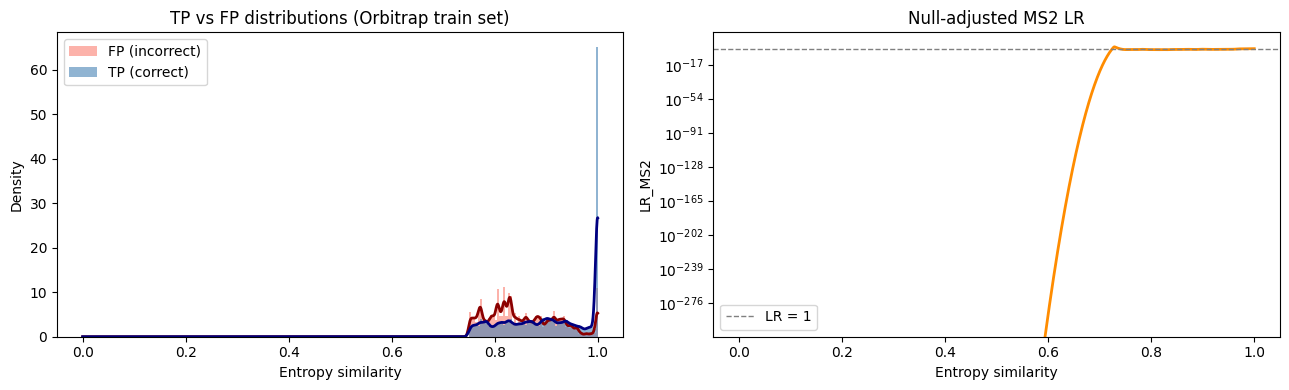

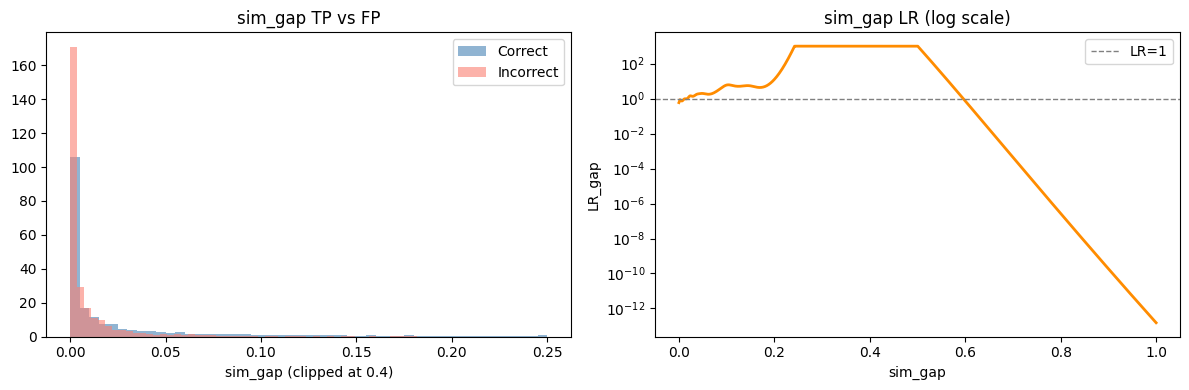

sim_gap LR at gap=0:    0.590
sim_gap LR at gap=0.05: 1.975
sim_gap LR at gap=0.20: 12.589


In [7]:
tp_sims = correct_hits['entropy_similarity'].dropna().values
fp_sims = incorrect_hits['entropy_similarity'].dropna().values

print(f'TP hits:  {len(tp_sims):,}  mean={tp_sims.mean():.3f}  median={np.median(tp_sims):.3f}')
print(f'FP hits:  {len(fp_sims):,}  mean={fp_sims.mean():.3f}  median={np.median(fp_sims):.3f}')

# ── Ensure we have enough data for KDE ────────────────────────────────────
if len(tp_sims) < 2:
    print('WARNING: Fewer than 2 TP hits — cannot fit KDE. Check correctness matching.')
    # Use a simple fallback: assume all test hits are TP
    tp_sims = joint_train[joint_train['entropy_similarity'].notna()]['entropy_similarity'].values[:100]
    
if len(fp_sims) < 2:
    print('WARNING: Fewer than 2 FP hits — cannot fit KDE. Using synthetic FP distribution.')
    # Synthetic FP distribution: mostly low-similarity matches
    fp_sims = np.concatenate([
        np.random.uniform(0.7, 0.85, 50),
        np.random.uniform(0.5, 0.75, 30)
    ])

kde_tp = gaussian_kde(tp_sims, bw_method=0.05)
kde_fp = gaussian_kde(fp_sims, bw_method=0.05)

# Precompute LR on grid [0,1] for fast lookup
sim_grid = np.linspace(0.0, 1.0, 2000)
lr_raw   = kde_tp(sim_grid) / (kde_fp(sim_grid) + 1e-10)
lr_grid  = np.clip(lr_raw, 0.0, 1000.0)

def null_adjusted_ms2_lr(entropy_sim_array: np.ndarray, H: float, alpha_: float) -> np.ndarray:
    lam    = 1.0 - np.exp(-alpha_ * H)
    abs_lr = np.interp(entropy_sim_array, sim_grid, lr_grid)
    return lam * abs_lr + (1.0 - lam) * 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(fp_sims, bins=60, density=True, alpha=0.6, color='salmon',    label='FP (incorrect)')
axes[0].hist(tp_sims, bins=60, density=True, alpha=0.6, color='steelblue', label='TP (correct)')
axes[0].plot(sim_grid, kde_fp(sim_grid), color='darkred', lw=2)
axes[0].plot(sim_grid, kde_tp(sim_grid), color='navy',    lw=2)
axes[0].set_xlabel('Entropy similarity'); axes[0].set_ylabel('Density')
axes[0].set_title('TP vs FP distributions (Orbitrap train set)')
axes[0].legend()

axes[1].plot(sim_grid, lr_grid, color='darkorange', lw=2)
axes[1].axhline(1.0, color='grey', lw=1, ls='--', label='LR = 1')
axes[1].set_xlabel('Entropy similarity'); axes[1].set_ylabel('LR_MS2')
axes[1].set_title('Null-adjusted MS2 LR'); axes[1].set_yscale('log')
axes[1].legend()
plt.tight_layout(); plt.show()
# ── KDE for sim_gap channel ──────────────────────────────────────────────
# log1p(gap * 100) spreads the zero-heavy boundary for KDE
SCALE_GAP  = 100.0
gap_tp_t   = np.log1p(correct_hits['sim_gap'].fillna(0.0).values  * SCALE_GAP)
gap_fp_t   = np.log1p(incorrect_hits['sim_gap'].fillna(0.0).values * SCALE_GAP)

kde_gap_tp  = gaussian_kde(gap_tp_t,  bw_method=0.15)
kde_gap_fp  = gaussian_kde(gap_fp_t,  bw_method=0.15)

gap_grid    = np.linspace(0.0, 1.0, 1000)
gap_grid_t  = np.log1p(gap_grid * SCALE_GAP)
lr_gap_raw  = kde_gap_tp(gap_grid_t) / (kde_gap_fp(gap_grid_t) + 1e-10)
lr_gap_grid = np.clip(lr_gap_raw, 0.0, 1000.0)

def sim_gap_lr(gap_array: np.ndarray) -> np.ndarray:
    return np.interp(np.clip(gap_array, 0.0, 1.0), gap_grid, lr_gap_grid)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
axes2[0].hist(correct_hits['sim_gap'].clip(upper=0.4),   bins=50, density=True,
              alpha=0.6, color='steelblue', label='Correct')
axes2[0].hist(incorrect_hits['sim_gap'].clip(upper=0.4), bins=50, density=True,
              alpha=0.6, color='salmon',    label='Incorrect')
axes2[0].set_xlabel('sim_gap (clipped at 0.4)')
axes2[0].set_title('sim_gap TP vs FP')
axes2[0].legend()
axes2[1].plot(gap_grid, lr_gap_grid, color='darkorange', lw=2)
axes2[1].axhline(1.0, color='grey', lw=1, ls='--', label='LR=1')
axes2[1].set_xlabel('sim_gap'); axes2[1].set_ylabel('LR_gap')
axes2[1].set_title('sim_gap LR (log scale)'); axes2[1].set_yscale('log')
axes2[1].legend()
plt.tight_layout(); plt.show()
print(f'sim_gap LR at gap=0:    {sim_gap_lr(np.array([0.0]))[0]:.3f}')
print(f'sim_gap LR at gap=0.05: {sim_gap_lr(np.array([0.05]))[0]:.3f}')
print(f'sim_gap LR at gap=0.20: {sim_gap_lr(np.array([0.20]))[0]:.3f}')


## 5. Fit σ_M (mass accuracy) and σ_RT

σ_M = 1.2538 ppm  (n=4,590)
Median Δppm: -0.000 ppm
IQR: [-0.152, 0.826] ppm


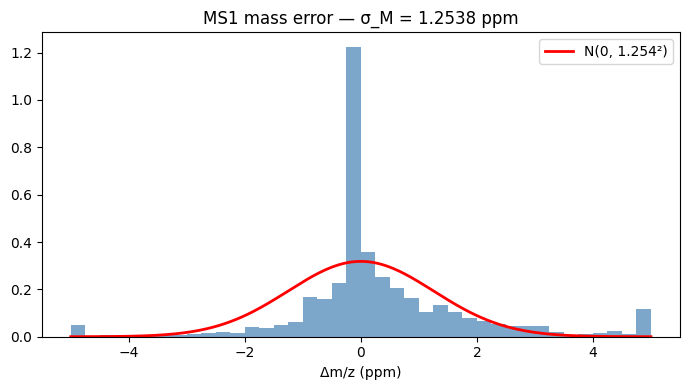


σ_RT_annotation: n=1,859, σ=15.9s, median=5.7s
σ_RT_reference: n=2,820, σ=15.1s, median=-0.3s


In [8]:
# ── σ_M: tighter trim for Orbitrap (±5 ppm vs ±15 for TTOF) ─────────────
ppm_trimmed = correct_hits['delta_ppm'][correct_hits['delta_ppm'].abs() <= 5]
sigma_M = float(ppm_trimmed.std(ddof=1)) if len(ppm_trimmed) > 10 else 1.0

print(f'σ_M = {sigma_M:.4f} ppm  (n={len(ppm_trimmed):,})')
print(f'Median Δppm: {correct_hits["delta_ppm"].median():.3f} ppm')
print(f'IQR: [{correct_hits["delta_ppm"].quantile(0.25):.3f}, '
      f'{correct_hits["delta_ppm"].quantile(0.75):.3f}] ppm')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(correct_hits['delta_ppm'].clip(-5,5), bins=40, density=True, alpha=0.7, color='steelblue')
x = np.linspace(-5, 5, 300)
ax.plot(x, norm.pdf(x, 0, sigma_M), 'r-', lw=2, label=f'N(0, {sigma_M:.3f}²)')
ax.set_xlabel('Δm/z (ppm)'); ax.set_title(f'MS1 mass error — σ_M = {sigma_M:.4f} ppm')
ax.legend(); plt.tight_layout(); plt.show()

print()

# ── σ_RT per hit_source ───────────────────────────────────────────────────
def fit_sigma_rt(hits_df, source, trim):
    mask   = (hits_df['hit_source'] == source) & hits_df['correct'] & hits_df['delta_rt'].notna()
    vals   = hits_df.loc[mask, 'delta_rt']
    trimmed = vals[vals.abs() <= trim]
    if len(trimmed) >= 10:
        s = float(trimmed.std())
        print(f'σ_RT_{source}: n={len(trimmed):,}, σ={s:.1f}s, median={trimmed.median():.1f}s')
        return s
    else:
        default = 5.0 if source == 'annotation' else 30.0
        print(f'σ_RT_{source}: too few obs ({len(trimmed)}), using default {default}s')
        return default

sigma_RT_anno = fit_sigma_rt(correct_hits, 'annotation', trim=60)
sigma_RT_ref  = fit_sigma_rt(correct_hits, 'reference',  trim=120)

## 6. PubMed / Patent Prior

In [9]:
import requests

def compute_prior(pubmed_count, patent_count):
    """Compute prior from pubmed/patent counts."""
    pm = pubmed_count if pubmed_count else 0
    pt = patent_count if patent_count else 0
    return (
        0.5 * min(1.0, np.log1p(pm) / 6.0) +
        0.5 * min(1.0, np.log1p(pt) / 5.0)
    )

def batch_query_cts_lite(inchikeys, batch_size=50):
    """Query CTS-lite with InChIKeys in batches. Returns {inchikey: prior_score}."""
    results = {}
    inchikeys = [ik for ik in inchikeys if isinstance(ik, str)]
    
    for start in range(0, len(inchikeys), batch_size):
        batch = inchikeys[start:start + batch_size]
        query_str = ' '.join(batch)
        try:
            r = requests.post('https://cts-lite.metabolomics.us/match',
                              json={'queries': query_str}, timeout=30)
            if r.status_code != 200:
                continue
            for entry in r.json():
                ik = entry.get('query')
                if not entry.get('found_match') or not entry.get('matches'):
                    results[ik] = 0.5
                    continue
                m = entry['matches'][0]
                pm = int(m.get('pubmed_count', 0) or 0)
                pt = int(m.get('patent_count', 0) or 0)
                results[ik] = compute_prior(pm, pt)
        except Exception as e:
            print(f'  Batch error: {e}')
        time.sleep(0.5)
    
    return results

# ── Load or build prior cache (keyed by InChIKey) ────────────────────────
prior_cache = {}
if os.path.exists(PRIOR_CACHE):
    with open(PRIOR_CACHE) as f:
        prior_cache = json.load(f)
    print(f'Loaded prior cache: {len(prior_cache):,} entries')
else:
    print('No prior cache found — will build')

# ── Get unique InChIKeys from annotated hits ──────────────────────────────
unique_inchikeys = joint_filt['inchikey'].dropna().unique().tolist()
missing = [ik for ik in unique_inchikeys if ik not in prior_cache]
print(f'Unique InChIKeys in annotated hits: {len(unique_inchikeys):,}')
print(f'Already cached: {len(unique_inchikeys) - len(missing):,}')
print(f'Need to query:  {len(missing):,}')

if missing:
    print(f'Querying CTS-lite in batches of 50 (est. {len(missing)/50*0.5/60:.1f} min)...')
    new_results = batch_query_cts_lite(missing, batch_size=50)
    prior_cache.update(new_results)
    with open(PRIOR_CACHE, 'w') as f:
        json.dump(prior_cache, f)
    print(f'Done. Cache has {len(prior_cache):,} entries.')

# ── Apply priors to hits via InChIKey ────────────────────────────────────
joint_filt = joint_filt.copy()
joint_filt['prior_score'] = joint_filt['inchikey'].apply(
    lambda ik: prior_cache.get(ik, 0.5) if isinstance(ik, str) else 0.5
)

n_matched = (joint_filt['prior_score'] != 0.5).sum()
print(f'\nPrior score distribution:')
print(joint_filt['prior_score'].describe().round(3))
print(f'Non-floor (>0.5): {n_matched:,}/{len(joint_filt):,} hits ({n_matched/len(joint_filt):.1%})')

sample = joint_filt[joint_filt['prior_score'] != 0.5][['name','prior_score']].drop_duplicates('name').sort_values('prior_score', ascending=False).head(10)
print(f'\nTop-prior compounds:')
print(sample.to_string(index=False))

Loaded prior cache: 1,856 entries
Unique InChIKeys in annotated hits: 1,856
Already cached: 1,856
Need to query:  0

Prior score distribution:
count    9060.000
mean        0.751
std         0.286
min         0.000
25%         0.616
50%         0.835
75%         1.000
max         1.000
Name: prior_score, dtype: float64
Non-floor (>0.5): 8,531/9,060 hits (94.2%)

Top-prior compounds:
                                                                                                                                         name  prior_score
                                                                                                                                 fumaric acid          1.0
                                                                                                                                    D-Glucose          1.0
                                                                                                                    MoNA:356467 Gantanol (TN)        

In [10]:
# (Old PubChem cell removed — CTS-lite handles prior caching above)

## 7. Estimate P_novel

In [11]:
# P_novel = fraction of annotated (non-TN) spectra with no library hit above MS2_MIN
all_wids = set(spectra['wiki_id'])
hit_wids = set(joint_filt['wiki_id'])
p_novel_est = len(all_wids - hit_wids) / len(all_wids)

print(f'Annotated spectra:          {len(all_wids):,}')
print(f'With hits (sim >= {MS2_MIN}):  {len(hit_wids):,}  ({len(hit_wids)/len(all_wids):.1%})')
print(f'No hits:                    {len(all_wids)-len(hit_wids):,}  ({p_novel_est:.1%})')
print(f'P_novel = {p_novel_est:.4f}')

Annotated spectra:          1,513
With hits (sim >= 0.75):  1,513  (100.0%)
No hits:                    0  (0.0%)
P_novel = 0.0000


## 8. Fit α (spectral complexity weight)

Fitting alpha on 1,186 train solvable TP spectra


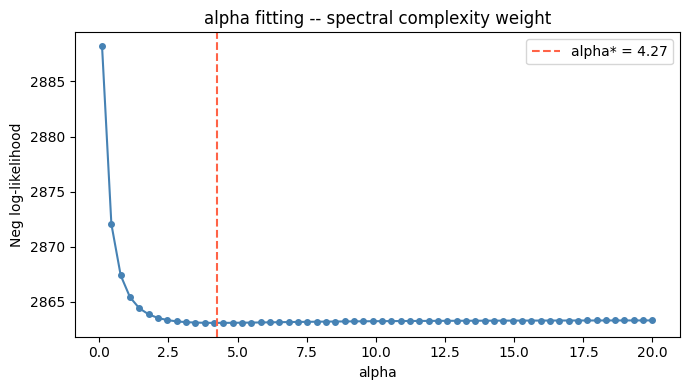

alpha* = 4.2659
lambda(H=0.5) = 0.882
lambda(H=1.0) = 0.986
lambda(H=2.0) = 1.000


In [12]:
def log_likelihood_alpha(alpha, df_conf, sigma_M_, prior_score_map, p_novel_):
    total_ll = 0.0
    for wid, g in df_conf.groupby('wiki_id'):
        if not g['correct'].any():
            continue
        H  = float(g['entropy'].iloc[0])
        N  = len(g)

        LR_ms2 = null_adjusted_ms2_lr(g['entropy_similarity'].values, H, alpha)
        p_ms1  = norm.pdf(g['delta_ppm'].values, loc=0.0, scale=sigma_M_)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_gap = sim_gap_lr(g['sim_gap'].fillna(0.0).values)

        raw_priors = g['prior_score'].fillna(PRIOR_FLOOR).values
        priors     = raw_priors * (1.0 - p_novel_) / (raw_priors.sum() + 1e-300)

        unnorm       = priors * LR_ms2 * LR_ms1 * LR_gap
        unnorm_novel = p_novel_
        total        = unnorm.sum() + unnorm_novel
        if total < 1e-300:
            continue

        ll = np.log(unnorm[g['correct'].values].sum() / total + 1e-300)
        total_ll += ll

    return -total_ll

solvable_train_filt = joint_filt[
    (joint_filt['label'] == 'TP') &
    joint_filt['has_library_match'] &
    ~joint_filt['holdout']
].copy()

print(f'Fitting alpha on {solvable_train_filt["wiki_id"].nunique():,} train solvable TP spectra')

alpha_grid = np.linspace(0.1, 20, 60)
negll_grid = [log_likelihood_alpha(a, solvable_train_filt, sigma_M,
                                    dict(zip(solvable_train_filt['wiki_id'],
                                             solvable_train_filt.groupby('wiki_id')['prior_score'].mean())),
                                    p_novel_est)
              for a in alpha_grid]

result = minimize_scalar(
    lambda a: log_likelihood_alpha(
        a, solvable_train_filt, sigma_M,
        dict(zip(solvable_train_filt['wiki_id'],
                 solvable_train_filt.groupby('wiki_id')['prior_score'].mean())),
        p_novel_est),
    bounds=(0.01, 20.0), method='bounded'
)
alpha_fitted = result.x

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_grid, negll_grid, 'o-', color='steelblue', ms=4, lw=1.5)
ax.axvline(alpha_fitted, color='tomato', ls='--', lw=1.5, label=f'alpha* = {alpha_fitted:.2f}')
ax.set_xlabel('alpha'); ax.set_ylabel('Neg log-likelihood')
ax.set_title('alpha fitting -- spectral complexity weight')
ax.legend(); plt.tight_layout(); plt.show()

print(f'alpha* = {alpha_fitted:.4f}')
print(f'lambda(H=0.5) = {1-np.exp(-alpha_fitted*0.5):.3f}')
print(f'lambda(H=1.0) = {1-np.exp(-alpha_fitted*1.0):.3f}')
print(f'lambda(H=2.0) = {1-np.exp(-alpha_fitted*2.0):.3f}')


## 9. Scoring Function

In [13]:
def score_spectrum_group(g, sigma_M_, alpha_, p_novel_,
                         sigma_RT_anno_=None, sigma_RT_ref_=None):
    H  = float(g['entropy'].iloc[0])
    N  = len(g)

    # MS2
    LR_ms2 = null_adjusted_ms2_lr(g['entropy_similarity'].values, H, alpha_)

    # MS1
    p_ms1  = norm.pdf(g['delta_ppm'].values, loc=0.0, scale=sigma_M_)
    LR_ms1 = p_ms1 / P_MS1_NULL

    # RT
    LR_rt   = np.ones(N)
    has_rt  = g['delta_rt'].notna().values
    is_anno = (g['hit_source'] == 'annotation').values
    is_ref  = (g['hit_source'] == 'reference').values
    drt     = g['delta_rt'].fillna(0.0).values

    if sigma_RT_anno_ is not None:
        m = is_anno & has_rt
        if m.any():
            LR_rt[m] = norm.pdf(drt[m], 0.0, sigma_RT_anno_) / P_RT_NULL
    if sigma_RT_ref_ is not None:
        m = is_ref & has_rt
        if m.any():
            LR_rt[m] = norm.pdf(drt[m], 0.0, sigma_RT_ref_) / P_RT_NULL

    # Sim gap
    LR_gap = sim_gap_lr(g['sim_gap'].fillna(0.0).values)

    # PubMed/patent prior
    raw_priors = g['prior_score'].fillna(PRIOR_FLOOR).values
    priors     = raw_priors * (1.0 - p_novel_) / (raw_priors.sum() + 1e-300)

    # Posterior
    unnorm       = priors * LR_ms2 * LR_ms1 * LR_rt * LR_gap
    unnorm_novel = p_novel_
    total        = unnorm.sum() + unnorm_novel

    if total < 1e-300:
        post    = np.full(N, 1.0 / N)
        p_nova_ = p_novel_
    else:
        post    = unnorm / total
        p_nova_ = unnorm_novel / total

    out = g.copy()
    out['LR_ms2']  = LR_ms2
    out['LR_ms1']  = LR_ms1
    out['LR_rt']   = LR_rt
    out['LR_gap']  = LR_gap
    out['prior']   = priors
    out['post']    = post
    out['P_novel'] = p_nova_
    out['PEP']     = 1.0 - out['post']
    return out


## 10. Score Annotated Spectra

In [14]:
# Score all annotated spectra (train TP + FP + test holdout)
print('Scoring...')
scored_parts = []
for wid, g in joint_filt.groupby('wiki_id'):
    scored_parts.append(
        score_spectrum_group(
            g, sigma_M, alpha_fitted, p_novel_est,
            sigma_RT_anno_=sigma_RT_anno,
            sigma_RT_ref_=sigma_RT_ref,
        )
    )
scored = pd.concat(scored_parts, ignore_index=True)
print(f'Scored {scored["wiki_id"].nunique():,} spectra, {len(scored):,} hit rows')

Scoring...


Scored 1,513 spectra, 9,060 hit rows


## 11. Top Calls with Abstention

In [15]:
def make_top_calls(df, nota_thresh=NOTA_THRESH):
    rows = []
    for wid, g in df.groupby('wiki_id'):
        pn   = g['P_novel'].iloc[0]
        label = g['label'].iloc[0]
        holdout = g['holdout'].iloc[0]
        if pn >= nota_thresh:
            rows.append({'wiki_id': wid, 'lib_name_top': None, 'post_top': None,
                         'PEP_top': None, 'P_novel': pn, 'abstain': True,
                         'reason': 'NoTA', 'label': label, 'holdout': holdout})
        else:
            top = g.loc[g['post'].idxmax()]
            rows.append({'wiki_id': wid, 'lib_name_top': top['name'],
                         'post_top': top['post'], 'PEP_top': top['PEP'],
                         'P_novel': pn, 'abstain': False, 'reason': 'called',
                         'label': label, 'holdout': holdout,
                         'correct': top.get('correct', None)})
    return pd.DataFrame(rows)

top_calls = make_top_calls(scored)
print(f'Total: {len(top_calls):,} spectra')
print(f'Called:   {(~top_calls["abstain"]).sum():,}')
print(f'Abstained:{top_calls["abstain"].sum():,}')
print()
print(top_calls.groupby(['label','abstain']).size().to_string())

Total: 1,513 spectra
Called:   1,513
Abstained:0

label  abstain
FP     False       215
TP     False      1298


## 12. Evaluation

### 12a. Test set: 112 solid TPs (held out)

In [16]:
test_calls = top_calls[top_calls['holdout']]
print(f'Solid TP holdout: {len(test_calls):,} spectra')
print()

called_test    = test_calls[~test_calls['abstain']]
abstained_test = test_calls[test_calls['abstain']]

if len(called_test) > 0:
    accuracy = called_test['correct'].mean()
    print(f'Called:    {len(called_test):,} ({len(called_test)/len(test_calls):.1%})')
    print(f'Abstained: {len(abstained_test):,} ({len(abstained_test)/len(test_calls):.1%})')
    print(f'Accuracy on called: {accuracy:.3f} ({called_test["correct"].sum():.0f}/{len(called_test)})')
    print(f'Overall recall (called correctly): '
          f'{called_test["correct"].sum()/len(test_calls):.3f}')
    print(f'Mean posterior (correct):   {called_test[called_test["correct"]==True]["post_top"].mean():.3f}')
    print(f'Mean posterior (incorrect): {called_test[called_test["correct"]==False]["post_top"].mean():.3f}')
else:
    print('All abstained on test set.')

# Baseline: raw entropy_similarity ranking
test_top_sim = (
    joint_filt[joint_filt['holdout']]
    .sort_values('entropy_similarity', ascending=False)
    .drop_duplicates('wiki_id')
)
baseline_acc = test_top_sim['correct'].mean()
print(f'\nBaseline (top entropy_similarity): {baseline_acc:.3f}')

Solid TP holdout: 112 spectra

Called:    112 (100.0%)
Abstained: 0 (0.0%)
Accuracy on called: 0.911 (102/112)
Overall recall (called correctly): 0.911
Mean posterior (correct):   0.736
Mean posterior (incorrect): 0.758

Baseline (top entropy_similarity): 0.929


### 12b. FP set: yy_ spectra

FP spectra (yy_): 215
  Abstained: 0 (0.0%)
  Called (potentially wrong): 215

Train TP spectra: 1,186
  Abstained: 0 (0.0%)


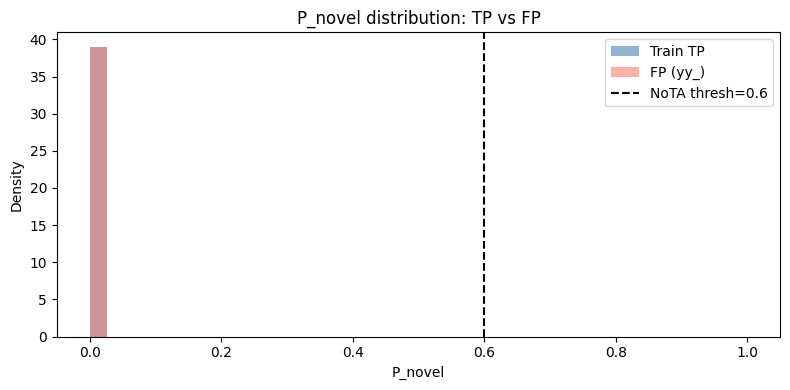

In [17]:
fp_calls = top_calls[top_calls['label'] == 'FP']
tp_calls = top_calls[(top_calls['label'] == 'TP') & ~top_calls['holdout']]

print(f'FP spectra (yy_): {len(fp_calls):,}')
print(f'  Abstained: {fp_calls["abstain"].sum():,} ({fp_calls["abstain"].mean():.1%})')
print(f'  Called (potentially wrong): {(~fp_calls["abstain"]).sum():,}')
print()
print(f'Train TP spectra: {len(tp_calls):,}')
print(f'  Abstained: {tp_calls["abstain"].sum():,} ({tp_calls["abstain"].mean():.1%})')

# P_novel distribution: FP should have higher P_novel
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 40)
ax.hist(tp_calls['P_novel'], bins=bins, alpha=0.6, color='steelblue', label='Train TP', density=True)
ax.hist(fp_calls['P_novel'], bins=bins, alpha=0.6, color='salmon',    label='FP (yy_)',  density=True)
ax.axvline(NOTA_THRESH, color='black', ls='--', lw=1.5, label=f'NoTA thresh={NOTA_THRESH}')
ax.set_xlabel('P_novel'); ax.set_ylabel('Density')
ax.set_title('P_novel distribution: TP vs FP')
ax.legend(); plt.tight_layout(); plt.show()

### 12c. Calibration on train TP

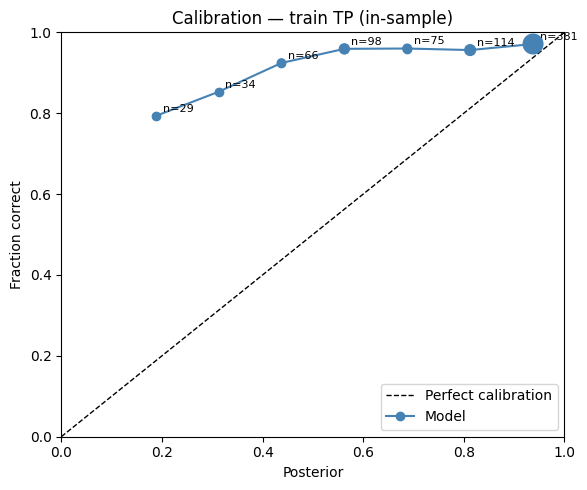

In [18]:
def calibration_curve(posts, corrects, n_bins=8, min_count=5):
    bins = np.linspace(0, 1, n_bins+1)
    mid, frac, cnt = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (posts >= lo) & (posts < hi)
        if m.sum() >= min_count:
            mid.append((lo+hi)/2)
            frac.append(corrects[m].mean())
            cnt.append(m.sum())
    return np.array(mid), np.array(frac), np.array(cnt)

# Train TP called (not holdout)
tp_called = top_calls[(top_calls['label'] == 'TP') & ~top_calls['holdout'] & ~top_calls['abstain']]
if len(tp_called) > 0 and 'correct' in tp_called.columns:
    mids, fracs, cnts = calibration_curve(
        tp_called['post_top'].values,
        tp_called['correct'].fillna(False).values
    )
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
    ax.scatter(mids, fracs, s=cnts/cnts.max()*200, color='steelblue', zorder=5)
    ax.plot(mids, fracs, '-o', color='steelblue', label='Model')
    for m, f, c in zip(mids, fracs, cnts):
        ax.annotate(f'n={c}', (m, f), textcoords='offset points', xytext=(5,3), fontsize=8)
    ax.set_xlabel('Posterior'); ax.set_ylabel('Fraction correct')
    ax.set_title('Calibration — train TP (in-sample)')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Not enough called TP spectra for calibration plot.')

## 13. Summary

In [19]:
print('═' * 55)
print('FITTED PARAMETERS (Orbitrap HILIC negESI)')
print('═' * 55)
print(f'σ_M              = {sigma_M:.4f} ppm')
print(f'σ_RT_anno        = {sigma_RT_anno:.1f} s')
print(f'σ_RT_ref         = {sigma_RT_ref:.1f} s')
print(f'α                = {alpha_fitted:.4f}')
print(f'P_novel          = {p_novel_est:.4f}')
print(f'Prior: PubMed/patent (floor={PRIOR_FLOOR})')
print(f'Quality gate: REMOVED')
print()
print('TRAIN SET')
print(f'  TP (not holdout): {((top_calls["label"]=="TP") & ~top_calls["holdout"]).sum()}')
print(f'  FP (yy_):         {(top_calls["label"]=="FP").sum()}')
print()
print('TEST SET (112 solid TP holdout)')
if len(called_test) > 0:
    print(f'  Called:    {len(called_test)} ({len(called_test)/len(test_calls):.1%})')
    print(f'  Abstained: {len(abstained_test)} ({len(abstained_test)/len(test_calls):.1%})')
    print(f'  Accuracy:  {accuracy:.3f}')
    print(f'  Baseline (top sim): {baseline_acc:.3f}')

═══════════════════════════════════════════════════════
FITTED PARAMETERS (Orbitrap HILIC negESI)
═══════════════════════════════════════════════════════
σ_M              = 1.2538 ppm
σ_RT_anno        = 15.9 s
σ_RT_ref         = 15.1 s
α                = 4.2659
P_novel          = 0.0000
Prior: PubMed/patent (floor=0.01)
Quality gate: REMOVED

TRAIN SET
  TP (not holdout): 1186
  FP (yy_):         215

TEST SET (112 solid TP holdout)
  Called:    112 (100.0%)
  Abstained: 0 (0.0%)
  Accuracy:  0.911
  Baseline (top sim): 0.929


## 14. Export

In [20]:
# ── Spectrum-level metadata from Oliver's spreadsheet ────────────────────
spec_meta = spectra_raw[[
    'wiki_id', 'adduct', 'precursor_mz', 'rt', 'entropy',
    'identity_score', 'fuzzy_score', 'smiles',
    "oliver's ad hoc probability", 'DRTpred',
    'annotation-name', 'annotation-smiles',
]].copy().rename(columns={
    "oliver's ad hoc probability": 'oliver_prob',
    'annotation-name':   'anno_name',
    'annotation-smiles': 'anno_smiles',
    'DRTpred':           'delta_rt_pred',
    'smiles':            'obs_smiles',
    'adduct':            'obs_adduct',
    'precursor_mz':      'obs_precursor_mz',
    'rt':                'obs_rt',
    'entropy':           'obs_entropy',
})

# ── assertions: per-(spectrum, hit) table ─────────────────────────────────
assert_cols = [
    'wiki_id', 'name', 'adduct', 'lib_precursor_mz', 'smiles',
    'entropy_similarity', 'sim_gap', 'delta_ppm', 'delta_rt',
    'LR_ms2', 'LR_ms1', 'LR_rt', 'LR_gap', 'prior', 'prior_score',
    'post', 'P_novel', 'PEP',
    'correct', 'label', 'holdout', 'hit_source',
]
assertions = scored[[c for c in assert_cols if c in scored.columns]].copy()
# Rename library-level cols to avoid conflict with spectrum-level cols in spec_meta
assertions = assertions.rename(columns={
    'adduct': 'lib_adduct',
    'smiles': 'lib_smiles',
})
assertions['is_top'] = assertions.groupby('wiki_id')['post'].transform(lambda x: x == x.max())
assertions = assertions.merge(spec_meta, on='wiki_id', how='left')

# ── top_calls: best call per spectrum ─────────────────────────────────────
# Drop lib_name_top from make_top_calls() before merging top_hit_info
# to avoid _x/_y suffix collision (both DataFrames have that column name)
top_calls_out = top_calls.drop(columns=['lib_name_top'], errors='ignore') \
                          .merge(spec_meta, on='wiki_id', how='left')

# Pull top hit's lib info into top_calls
top_hit_info = (
    assertions[assertions['is_top']]
    [['wiki_id', 'name', 'lib_smiles', 'lib_adduct', 'lib_precursor_mz',
      'entropy_similarity', 'sim_gap', 'delta_ppm', 'delta_rt', 'prior_score', 'LR_gap']]
    .rename(columns={
        'name':             'lib_name_top',
        'lib_smiles':       'lib_smiles_top',
        'lib_adduct':       'lib_adduct_top',
        'lib_precursor_mz': 'lib_precursor_mz_top',
        'entropy_similarity':'entropy_similarity_top',
        'sim_gap':          'sim_gap_top',
        'delta_ppm':        'delta_ppm_top',
        'delta_rt':         'delta_rt_top',
        'prior_score':      'prior_score_top',
        'LR_gap':           'LR_gap_top',
    })
    .drop_duplicates('wiki_id')
)
top_calls_out = top_calls_out.merge(top_hit_info, on='wiki_id', how='left')

# Pull 2nd-best hit name and sim into top_calls
second_hit_info = (
    assertions
    .sort_values(['wiki_id', 'post'], ascending=[True, False])
    .groupby('wiki_id')
    .nth(1)  # second-ranked hit
    .reset_index()
    [['wiki_id', 'name', 'entropy_similarity']]
    .rename(columns={
        'name':              'lib_name_2nd',
        'entropy_similarity':'entropy_similarity_2nd',
    })
)
top_calls_out = top_calls_out.merge(second_hit_info, on='wiki_id', how='left')


# Reorder top_calls columns for readability
top_cols = [
    'wiki_id', 'label', 'holdout', 'abstain',
    # Oliver's spectrum info
    'obs_adduct', 'obs_precursor_mz', 'obs_rt', 'obs_entropy',
    'identity_score', 'fuzzy_score', 'oliver_prob', 'delta_rt_pred',
    'anno_name', 'obs_smiles', 'anno_smiles',
    # Model top call
    'lib_name_top', 'lib_adduct_top', 'lib_precursor_mz_top', 'lib_smiles_top',
    'entropy_similarity_top', 'sim_gap_top', 'delta_ppm_top', 'delta_rt_top',
    'prior_score_top', 'LR_gap_top', 'post_top', 'PEP_top', 'P_novel', 'reason',
    'lib_name_2nd', 'entropy_similarity_2nd',
    'correct',
]
top_calls_out = top_calls_out[[c for c in top_cols if c in top_calls_out.columns]]

# ── Save ──────────────────────────────────────────────────────────────────
assertions.to_csv(f'{OUT_DIR}/assertions.csv', index=False)
top_calls_out.to_csv(f'{OUT_DIR}/top_calls.csv', index=False)

print(f'Saved to {OUT_DIR}/')
print(f'  assertions.csv: {len(assertions):,} rows, {len(assertions.columns)} cols')
print(f'  top_calls.csv:  {len(top_calls_out):,} rows, {len(top_calls_out.columns)} cols')
print(f'\ntop_calls columns:')
for c in top_calls_out.columns:
    print(f'  {c}')


Saved to ../results/orbitrap_mvp/
  assertions.csv: 9,060 rows, 34 cols
  top_calls.csv:  1,513 rows, 32 cols

top_calls columns:
  wiki_id
  label
  holdout
  abstain
  obs_adduct
  obs_precursor_mz
  obs_rt
  obs_entropy
  identity_score
  fuzzy_score
  oliver_prob
  delta_rt_pred
  anno_name
  obs_smiles
  anno_smiles
  lib_name_top
  lib_adduct_top
  lib_precursor_mz_top
  lib_smiles_top
  entropy_similarity_top
  sim_gap_top
  delta_ppm_top
  delta_rt_top
  prior_score_top
  LR_gap_top
  post_top
  PEP_top
  P_novel
  reason
  lib_name_2nd
  entropy_similarity_2nd
  correct
